# BSCL Registration: C5-HC-4w → C6_Tr_4w

Регистрация двух реальных конфокальных серий из папки `data/BSCL`:

| Образец | Папка | Слайсов | Разрешение |
|---------|-------|---------|------------|
| Moving | `C5-HC-4w/Pattern 1` | 465 | 1472 × 2184, uint16 |
| Fixed  | `C6_Tr_4w/Pattern 1` | 497 | 1472 × 2184, uint16 |

Стратегия:
- Загружаем с `scale=8` (~11 MB) для SA-стадий
- Финальное уточнение GD на `scale=4` (~90 MB)
- `ratio` = отношение XY/Z разрешения микроскопа (по умолчанию 1.0)

In [1]:
# pip install -e ".[io]"  ← один раз в окружении
import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from brain_morph.utils import Volume, MeshTransformer3D
from brain_morph.registration import (
    registration_cost,
    Stage, RegistrationPipeline,
    SAOptimizer, GradientOptimizer,
)

# Project root
_cwd = Path(os.getcwd())
ROOT = str(_cwd.parent if _cwd.name == "notebooks" else _cwd)

print(f"torch {torch.__version__}  |  device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"ROOT: {ROOT}")

torch 2.9.0  |  device: cpu
ROOT: /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph


## 1. Пути к данным

In [2]:
BSCL_DIR = os.path.join(ROOT, 'data', 'BSCL')

MOVING_MASK = os.path.join(BSCL_DIR, 'C5-HC-4w',  'Pattern 1', 'Plane*.tif')
FIXED_MASK  = os.path.join(BSCL_DIR, 'C6_Tr_4w',  'Pattern 1', 'Plane*.tif')

OUTPUT_DIR  = os.path.join(ROOT, 'data', 'BSCL', 'results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Параметры загрузки ──────────────────────────────────────────────────────
SCALE_COARSE = 8     # уменьшение XY для SA-стадий: 1472→184, 2184→273
RATIO        = 1.6   # XY/Z разрешение; если Z-шаг вдвое крупнее XY → ratio=0.5

print(f'Moving: {MOVING_MASK}')
print(f'Fixed:  {FIXED_MASK}')

Moving: /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph/data/BSCL/C5-HC-4w/Pattern 1/Plane*.tif
Fixed:  /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph/data/BSCL/C6_Tr_4w/Pattern 1/Plane*.tif


## 2. Загрузка образцов

In [3]:
print('Загрузка moving (C5-HC-4w) ...')
vol_moving = Volume.load_tiff_series(MOVING_MASK, scale=SCALE_COARSE, ratio=RATIO)
print(f'  moving: {tuple(vol_moving.shape)}  dtype={vol_moving.dtype}')

print('Загрузка fixed (C6_Tr_4w) ...')
vol_fixed = Volume.load_tiff_series(FIXED_MASK, scale=SCALE_COARSE, ratio=RATIO)
print(f'  fixed:  {tuple(vol_fixed.shape)}  dtype={vol_fixed.dtype}')

# Нормализовать в [0, 1] float32, оставить форму (1, D, H, W)
def norm_vol(v: Volume) -> Volume:
    t = v.float()
    return (t / t.max().clamp_min(1e-6)).as_subclass(Volume)

vol_moving = norm_vol(vol_moving)
vol_fixed  = norm_vol(vol_fixed)

# Обрезать fixed по D до размера moving (разное число слайсов)
D = vol_moving.shape[1]
vol_fixed = vol_fixed[:, :D].as_subclass(Volume)

# (1, D, H, W) — для регистрации и visualize
im_moving = vol_moving   # Volume (1, D, H, W)
im_fixed  = vol_fixed    # Volume (1, D, H, W)

H, W = im_moving.shape[2], im_moving.shape[3]
print(f'\nim_moving: {tuple(im_moving.shape)}  im_fixed: {tuple(im_fixed.shape)}')

Загрузка moving (C5-HC-4w) ...
  moving: (1, 93, 184, 273)  dtype=torch.float32
Загрузка fixed (C6_Tr_4w) ...
  fixed:  (1, 100, 184, 273)  dtype=torch.float32

im_moving: (1, 93, 184, 273)  im_fixed: (1, 93, 184, 273)


## 3. Предварительный просмотр

=== Moving: C5-HC-4w ===


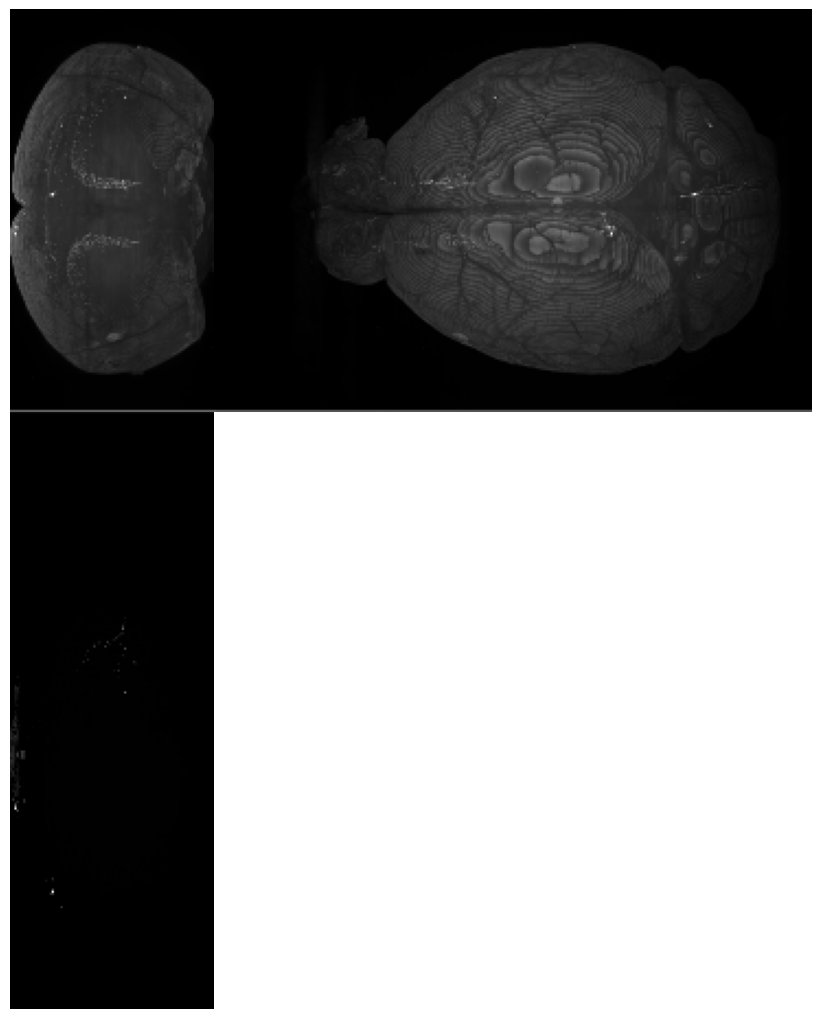

In [4]:
print('=== Moving: C5-HC-4w ===')
im_moving.visualize(channel=0)

=== Fixed: C6_Tr_4w (обрезанный) ===


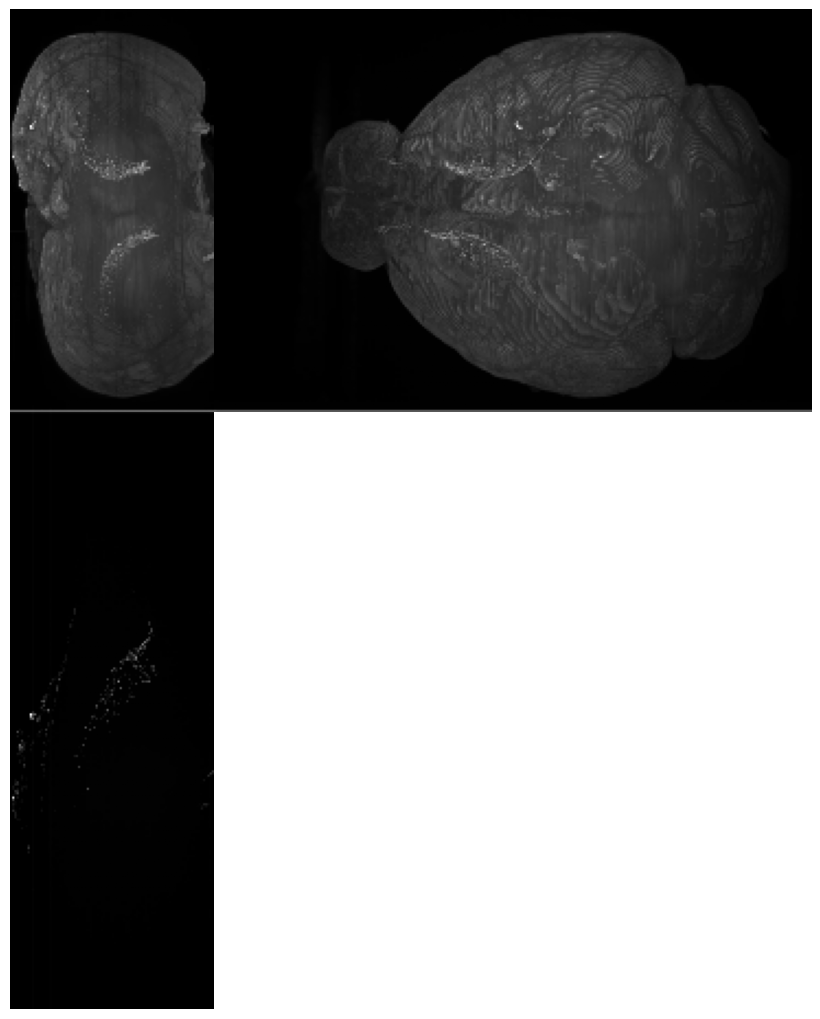

In [5]:
print('=== Fixed: C6_Tr_4w (обрезанный) ===')
im_fixed.visualize(channel=0)

## 4. Baseline: identity

NCC (identity): 0.7887
=== |moving − fixed| до регистрации ===


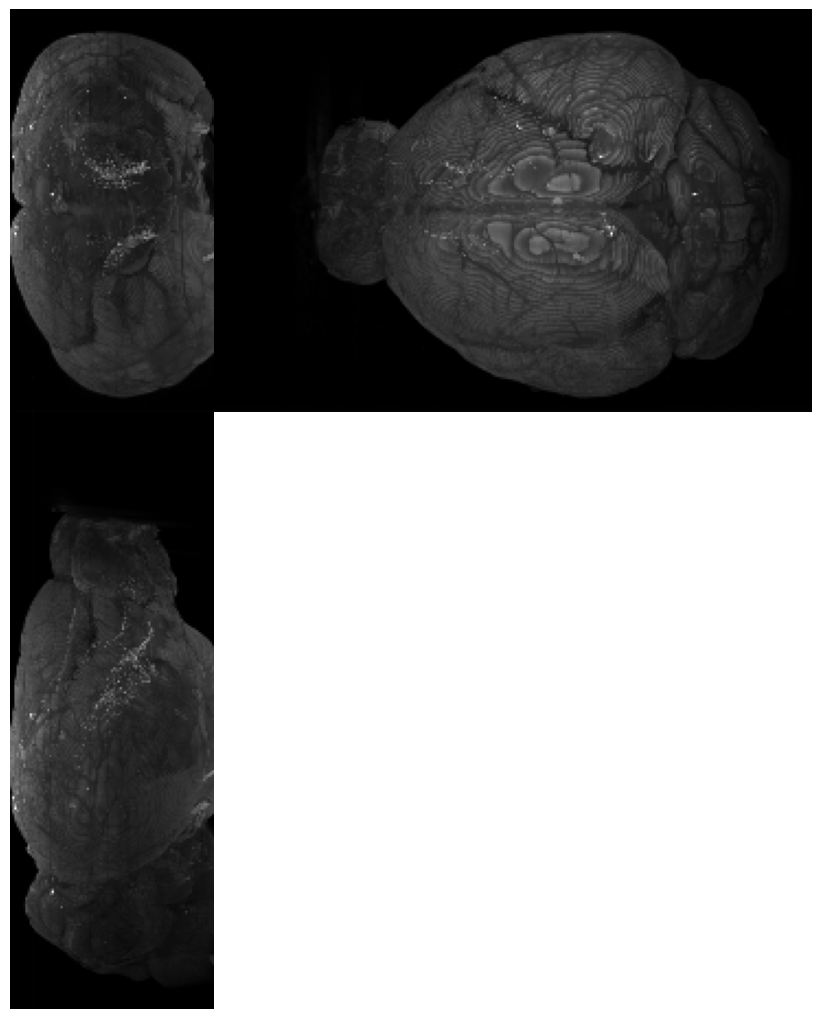

In [6]:
grid_init = torch.stack(
    torch.meshgrid(*[torch.linspace(-1, 1, s) for s in (4, 4, 4)], indexing='ij'),
    dim=-1,
)
# transform ожидает (C, D, H, W) → возвращает (C, D, H, W)
t_base = MeshTransformer3D(grid_init, (D, H, W))

with torch.no_grad():
    warped_id = t_base.transform(im_moving, grid_init)   # (1, D, H, W)

cost_id = registration_cost(
    im_moving, im_fixed, t_base, grid_init, lam=0, similarity='ncc'
).item()
print(f'NCC (identity): {cost_id:.4f}')

print('=== |moving − fixed| до регистрации ===')
Volume((warped_id - im_fixed).abs()).visualize(channel=0)

## 5. Настройка пайплайна

| Стадия | Сетка | Шагов | λ | Scale |
|--------|-------|-------|---|-------|
| SA-1 (грубая) | 2×2×2 | 2000 | 5e-2 | ×8 |
| SA-2 | 4×4×3 | 2000 | 2e-2 | ×8 |
| SA-3 | 5×5×4 | 2000 | 1e-2 | ×4 |
| GD-refine | 5×5×4 | 400  | 2e-3 | ×1 |

In [7]:
cost_log = []

def _cb(step, cost, warped):
    cost_log.append((step, cost))

_sa_kw = dict(
    coeff_start=0.12, coeff_drop=0.9966,
    attention_freq=50,
    callback=_cb, callback_freq=50,
    similarity='ncc',
)

sa_1 = SAOptimizer(temp_start=2e-3, temp_end=2e-5, **_sa_kw)
sa_2 = SAOptimizer(temp_start=1e-3, temp_end=1e-5, **_sa_kw)
sa_3 = SAOptimizer(temp_start=5e-4, temp_end=5e-6, **_sa_kw)
gd   = GradientOptimizer(
    optimizer_cls=torch.optim.Adam, lr=5e-4,
    tension_mode='squared', similarity='ncc',
)

pipeline = RegistrationPipeline([
    Stage(grid_shape=(2, 2, 2), optimizer=sa_1, n_steps=300, lam=5e-2, image_scale=8),
    Stage(grid_shape=(4, 4, 3), optimizer=sa_2, n_steps=300, lam=2e-2, image_scale=8),
    Stage(grid_shape=(5, 5, 4), optimizer=sa_3, n_steps=300, lam=1e-2, image_scale=4),
    Stage(grid_shape=(5, 5, 4), optimizer=gd,   n_steps=50,  lam=2e-3, image_scale=1),
])
print('Пайплайн готов.')


Пайплайн готов.


## 6. Запуск регистрации

In [8]:
cost_log.clear()
grid_result = pipeline.run(im_moving, im_fixed)
clear_output(wait=True)
print(f'Готово. Итоговая сетка: {grid_result.shape}')

Готово. Итоговая сетка: torch.Size([5, 5, 4, 3])


## 7. Результат

NCC identity: 0.7887
NCC result:   0.8593  (Δ = +0.0706)
=== Warped moving ===


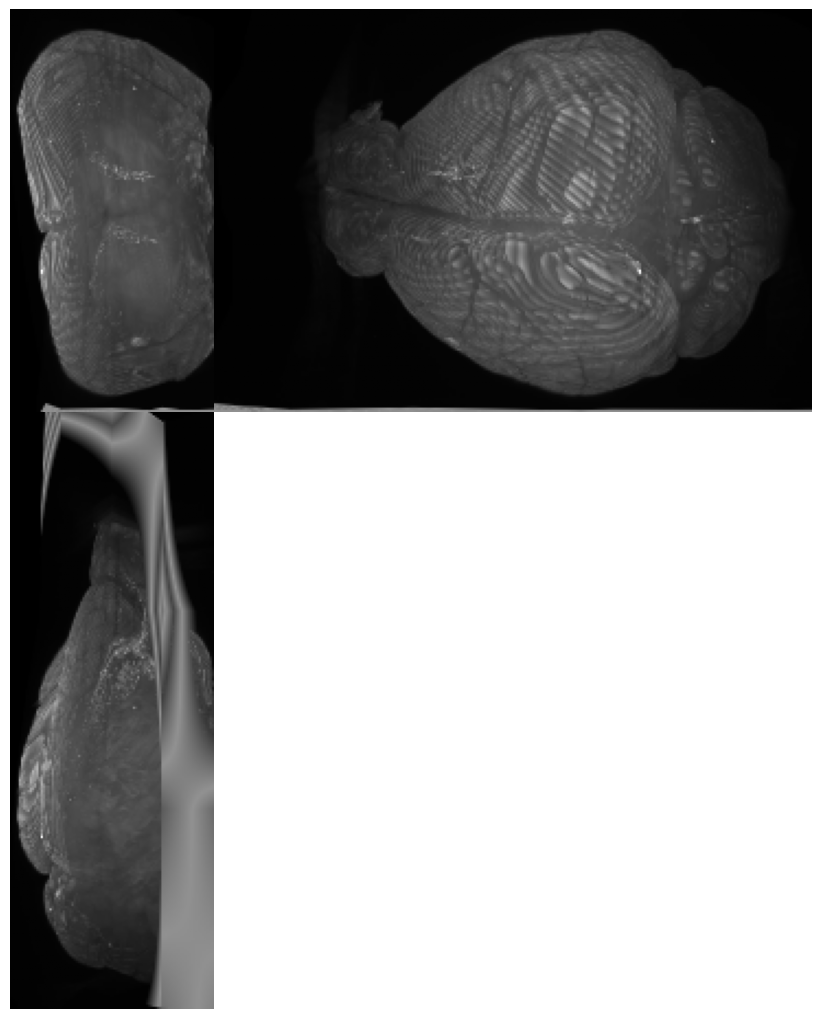

=== |warped − fixed| ===


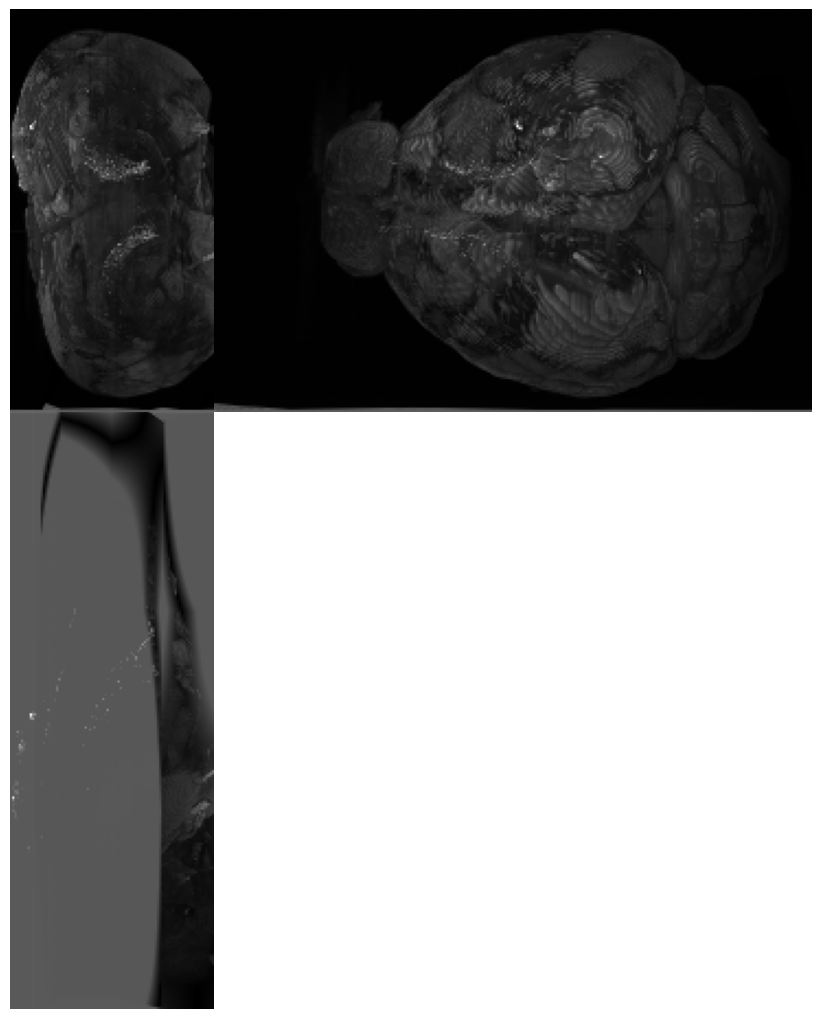

In [9]:
grid_init_final = torch.stack(
    torch.meshgrid(*[torch.linspace(-1, 1, s) for s in grid_result.shape[:3]], indexing='ij'),
    dim=-1,
)
t_final = MeshTransformer3D(grid_init_final, (D, H, W))

with torch.no_grad():
    warped_result = t_final.transform(im_moving, grid_result)

cost_result = registration_cost(
    im_moving, im_fixed, t_final, grid_result, lam=0, similarity='ncc'
).item()

print(f'NCC identity: {cost_id:.4f}')
print(f'NCC result:   {cost_result:.4f}  (Δ = {cost_result - cost_id:+.4f})')

print('=== Warped moving ===')
Volume(warped_result).visualize(channel=0)

print('=== |warped − fixed| ===')
Volume((warped_result - im_fixed).abs()).visualize(channel=0)

## 8. Сравнение до/после

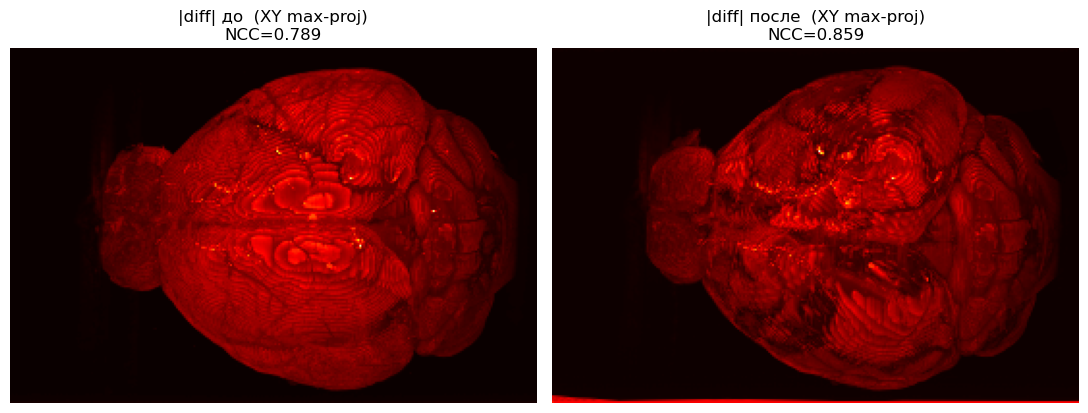

In [10]:
diff_before = (warped_id     - im_fixed).abs()
diff_after  = (warped_result - im_fixed).abs()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
vmax = max(diff_before.amax().item(), diff_after.amax().item())
axes[0].imshow(diff_before[0].amax(0).cpu(), cmap='hot', vmin=0, vmax=vmax)
axes[0].set_title(f'|diff| до  (XY max-proj)\nNCC={cost_id:.3f}'); axes[0].axis('off')
axes[1].imshow(diff_after[0].amax(0).cpu(),  cmap='hot', vmin=0, vmax=vmax)
axes[1].set_title(f'|diff| после  (XY max-proj)\nNCC={cost_result:.3f}'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 9. График метрики

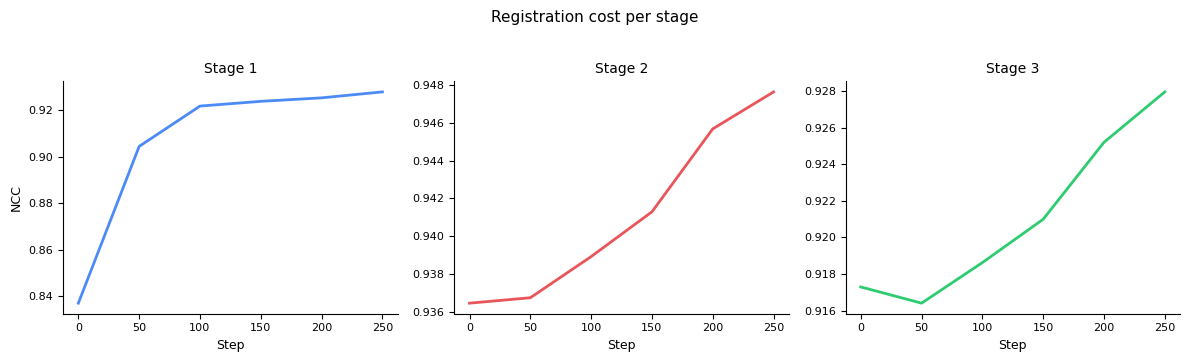

In [11]:
if cost_log:
    stages_data = []
    current = []
    for i, (s, c) in enumerate(cost_log):
        if i > 0 and s < cost_log[i-1][0]:
            stages_data.append(current)
            current = []
        current.append((s, c))
    stages_data.append(current)

    COLORS = ["#4C8BF5", "#E8555A", "#2ECC71", "#F5A623"]
    n = len(stages_data)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5))
    if n == 1:
        axes = [axes]

    for i, (stage_data, ax) in enumerate(zip(stages_data, axes)):
        steps_, costs_ = zip(*stage_data)
        color = COLORS[i % len(COLORS)]
        ax.plot(steps_, costs_, color=color, alpha=0.3, linewidth=0.7)
        import numpy as np
        w = max(1, len(costs_) // 20)
        sm = np.convolve(costs_, np.ones(w)/w, mode="same")
        ax.plot(steps_, sm, color=color, linewidth=2)
        ax.set_title(f"Stage {i+1}", fontsize=10)
        ax.set_xlabel("Step", fontsize=9)
        if i == 0:
            ax.set_ylabel("NCC", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=8)

    plt.suptitle("Registration cost per stage", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

## 10. Сохранение результата

In [12]:
import nibabel as nib
import numpy as np

out_nii  = os.path.join(OUTPUT_DIR, 'C5_warped_to_C6.nii.gz')
out_grid = os.path.join(OUTPUT_DIR, 'C5_to_C6_grid.pt')

arr = warped_result.cpu().numpy().astype(np.float32)
nib.save(nib.Nifti1Image(arr, affine=np.eye(4)), out_nii)
torch.save(grid_result, out_grid)

print(f'NIfTI сохранён:  {out_nii}')
print(f'Сетка сохранена: {out_grid}')

NIfTI сохранён:  /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph/data/BSCL/results/C5_warped_to_C6.nii.gz
Сетка сохранена: /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph/data/BSCL/results/C5_to_C6_grid.pt


## Приложение: повторное применение сетки

In [13]:
# grid_saved = torch.load(out_grid)
# grid_init_s = torch.stack(
#     torch.meshgrid(*[torch.linspace(-1, 1, s) for s in grid_saved.shape[:3]], indexing='ij'),
#     dim=-1,
# )
# t_saved = MeshTransformer3D(grid_init_s, im_moving.shape)
# with torch.no_grad():
#     warped_new = t_saved.transform(another_volume, grid_saved)